In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az
import gc
from pathlib import Path
from define_data_and_variables import hmc_config, data, hash_configs

# TODO: fix so that it is easy to run either with fixed dF or updating dF. Need to increase maximum temp. Maybe increase number of shared chains for this as well.:)


{'N': 50, 'nc14': 7, 'nd18o': 224, 'nd18or': 1000, 'H': 115, 'dc': 2.3, 'pm': 1.71472, 'ps': 0.7107, 'th': np.float64(2018.0), 'cs': array([  0. ,   2.3,   4.6,   6.9,   9.2,  11.5,  13.8,  16.1,  18.4,
        20.7,  23. ,  25.3,  27.6,  29.9,  32.2,  34.5,  36.8,  39.1,
        41.4,  43.7,  46. ,  48.3,  50.6,  52.9,  55.2,  57.5,  59.8,
        62.1,  64.4,  66.7,  69. ,  71.3,  73.6,  75.9,  78.2,  80.5,
        82.8,  85.1,  87.4,  89.7,  92. ,  94.3,  96.6,  98.9, 101.2,
       103.5, 105.8, 108.1, 110.4, 112.7, 115. ]), 'c14': array([1921., 1899., 1784., 1652., 1544., 1454., 1075.]), 'c14d': array([  6.,   9.,  29.,  48.,  65.,  80., 113.]), 'c14s': array([2. , 3. , 5. , 2.5, 7. , 2.5, 2.5]), 'ic14v': array([0.25      , 0.11111111, 0.04      , 0.16      , 0.02040816,
       0.16      , 0.16      ]), 'd18o': array([-9.24, -9.11, -8.93, -9.08, -9.51, -9.17, -9.71, -9.5 , -9.08,
       -9.56, -9.27, -9.32, -9.23, -9.36, -9.37, -9.31, -9.25, -9.29,
       -9.4 , -9.49, -9.36, -8.95

In [2]:
base_dir = Path.cwd()
np.random.seed(hmc_config["sd"])
sp = np.random.multivariate_normal(data["pm"]* np.ones(data["N"]), data["ps"]**2 * np.eye(data["N"]), (hmc_config["nch"]))
sp = np.exp(sp)
print(sp)
hmc_config["sp"] = np.ascontiguousarray(sp)
hmc_hash = hash_configs(hmc_config, data)
output_dir = base_dir / f"output/{hmc_hash}"

[[ 4.58286685  5.98487535  6.63773054  2.878244    8.31273769  2.65239743
   4.98036161  9.73831088  2.32390369  2.83196675  3.70568061  2.77391406
   3.21244408  5.42360859  2.66623385 12.51143638  3.60150124 15.78459124
  16.04772106  9.18226494  1.48273888  2.09723054  4.39344383  1.89231971
  13.03454022  1.52102519  6.72728466  4.04485699 12.26393297  2.08211373
  11.43160862  6.51413589  3.51358725  8.88949774 13.92422481  2.94003572
   3.70922003  1.23861378  3.10541917  2.80317854  6.06905761  6.00046598
   4.06538558  3.34542133 10.79024416  5.79158781 17.43960795 10.23543503
   2.75808391  2.81118931]
 [ 7.64385088  2.84314791  6.21929741  7.31937792  7.58017244  7.47792795
   3.30143138  2.01302647  1.33211676  4.70588799 20.02114467  1.39068963
  14.68536932  1.48247634  2.31116382  3.87284806 15.10154088  2.84590843
  10.33483072 12.44645331 12.72266583  5.7528578   7.9872766   8.70053464
  10.43963748  5.78745717  4.39519882  0.74227289  2.3971466   5.34275231
  13.489662

In [3]:
colors = plt.cm.viridis(np.linspace(0, 1, hmc_config["nch"]))

In [4]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

[[ 4.58286685  5.98487535  6.63773054  2.878244    8.31273769  2.65239743
   4.98036161  9.73831088  2.32390369  2.83196675  3.70568061  2.77391406
   3.21244408  5.42360859  2.66623385 12.51143638  3.60150124 15.78459124
  16.04772106  9.18226494  1.48273888  2.09723054  4.39344383  1.89231971
  13.03454022  1.52102519  6.72728466  4.04485699 12.26393297  2.08211373
  11.43160862  6.51413589  3.51358725  8.88949774 13.92422481  2.94003572
   3.70922003  1.23861378  3.10541917  2.80317854  6.06905761  6.00046598
   4.06538558  3.34542133 10.79024416  5.79158781 17.43960795 10.23543503
   2.75808391  2.81118931]
 [ 7.64385088  2.84314791  6.21929741  7.31937792  7.58017244  7.47792795
   3.30143138  2.01302647  1.33211676  4.70588799 20.02114467  1.39068963
  14.68536932  1.48247634  2.31116382  3.87284806 15.10154088  2.84590843
  10.33483072 12.44645331 12.72266583  5.7528578   7.9872766   8.70053464
  10.43963748  5.78745717  4.39519882  0.74227289  2.3971466   5.34275231
  13.489662

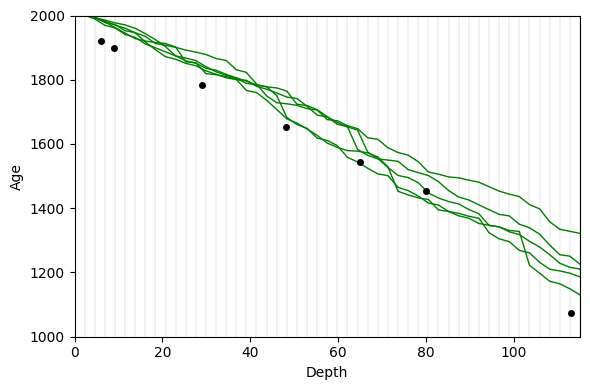

In [14]:
print(sp)
cumulative_sums = np.cumsum(sp, axis=1) * data["dc"]
zeros = np.zeros((*sp.shape[:1], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)
print(np.shape(age_offsets))

model_ages = data["th"] - age_offsets

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(sp)
for j in range(num_samples):
    ax.plot(
        data["cs"],
        model_ages[j, :],
        color='green',
        alpha=1,
        linewidth=1,
    )
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.set_xlim(0, np.max(data["cs"]))
ax.set_ylim(1000, 2000)
plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig(f"{output_dir}/sp_age_depth.jpg")
plt.show()

In [6]:
samples = np.load(f"{output_dir}/samples.npy")

In [7]:
# from matplotlib import colors

# chain = -1
# X = samples[:, 2000:, :].reshape(-1, data["N"]).T
# D, N = X.shape

# age = np.vstack([
#     np.ones((1, N)) * data["th"],
#     data["th"] - data["dc"] * np.cumsum(X, axis=0)
# ])

# # age_mean = np.mean(age, axis = 1)
# norm_age = age #- true_age[:, None]

# # Time bins
# dt = 1
# t_edges = np.arange(-2000, 2000 + dt, dt)
# t = t_edges[1:] - dt / 2
# T = t.size

# # Depth interpolation grid
# dz = 0.1
# z = np.arange(0, data["dc"] * D + dz, dz)
# Z = z.size

# # Allocate result
# C = np.full((Z, T), np.nan)
# A = np.array([
#     np.interp(z, data["cs"], norm_age[:, j])
#     for j in range(N)
# ]).T

# for i in range(Z):
#     C[i, :], _ = np.histogram(A[i, :], bins=t_edges, density = True)

# fig, ax = plt.subplots(figsize=(6, 4))
# plt.set_cmap(plt.cm.Greys)
# for i, c in enumerate(data["cs"]):
#     # if i ==index: 
#     #     ax.axvline(x=c, color='k', linestyle='--', linewidth = 1, label = f"d = {int(interesting_depth)} mm")
#     # else:
#     ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

# ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = r"$^{230}Th$")
# # ax.plot(data["cs"], true_ages, color = 'blue', linewidth=3, alpha = 0.2, label = r"$A_3(d)$")
# im = ax.imshow(
#     C.T,
#     extent=[z[0], z[-1], t[0], t[-1]],
#     origin='lower',
#     aspect='auto',
#     # vmin=0,
#     # vmax=0.01 * N,
#     norm=colors.LogNorm()
# )

# plt.legend(loc = "upper right")
# cbar = plt.colorbar(im)
# cbar.set_label("Marginal Density")
# plt.xlabel("Distance from top of stalagmite [mm]")
# plt.ylabel("Year CE")
# plt.savefig(f"{output_dir}/resampled_no_mean_{chain}.jpg")
# plt.show()

# del A, C
# gc.collect()


In [8]:
# cumulative_sums = np.cumsum(samples, axis=2) * data["dc"]
# zeros = np.zeros((*samples.shape[:2], 1))
# age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

# model_ages = data["th"] - age_offsets

# # Age depth trace plot
# fig, ax = plt.subplots(figsize=(6, 4))
# num_samples = len(samples[0,:,0])
# for i in range(hmc_config["nch"]):
#     for j in range(num_samples):
#         ax.plot(
#             data["cs"],
#             model_ages[i, j, :],
#             color=colors[i],
#             alpha=0.3,
#             linewidth=0.1,
#         )

# ax.set_xlim(0, np.max(data["cs"]))
# ax.set_ylim(1200, 2000)
# plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# plt.plot(data["d18od"], data["d18ota"], color = 'k', linewidth=0.5)
# plt.xlabel("Depth")
# plt.ylabel("Age")
# plt.tight_layout()
# plt.savefig(f"{output_dir}/age_depth_samples.jpg")
# plt.show()

In [9]:
# Print R_hat and N_eff using arviz
idata = az.convert_to_inference_data(samples[:, 2000:, :])
summary = az.summary(idata, round_to=2)
print(summary)

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd    ess_bulk  \
x[0]   18.10  10.48    1.78    34.76       0.02     0.01   542445.26   
x[1]   18.12  10.48    1.79    34.78       0.02     0.01   538659.02   
x[2]    9.74   5.45    1.20    19.61       0.01     0.02   650750.48   
x[3]    6.08   2.41    1.64    10.30       0.00     0.01   227040.68   
x[4]    5.75   3.53    0.76    12.31       0.01     0.01   358807.24   
x[5]    5.75   3.54    0.82    12.36       0.01     0.01   348055.33   
x[6]    5.77   3.56    0.76    12.40       0.01     0.01   349903.10   
x[7]    5.76   3.55    0.77    12.36       0.01     0.01   351307.95   
x[8]    5.75   3.53    0.76    12.30       0.01     0.02   361059.10   
x[9]    5.76   3.56    0.80    12.42       0.01     0.02   355195.61   
x[10]   5.75   3.52    0.77    12.27       0.01     0.01   349462.02   
x[11]   5.76   3.56    0.76    12.38       0.01     0.01   362264.34   
x[12]   6.39   4.33    0.72    14.38       0.01     0.02   51389

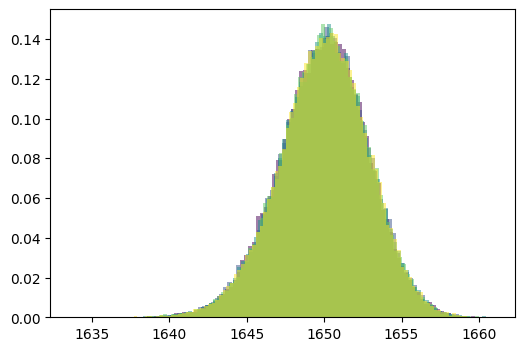

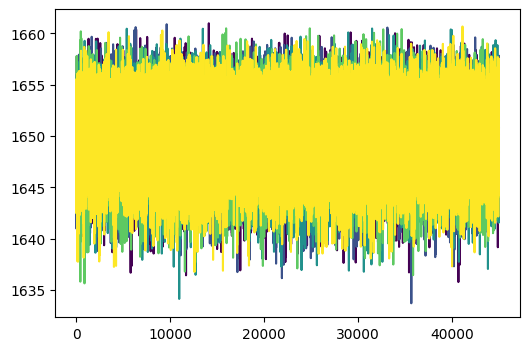

In [10]:
colors = plt.cm.viridis(np.linspace(0, 1, hmc_config["nch"]))
index = 21
interesting_depth = index * data["dc"]
CV_values = data["th"] - data["dc"] * np.sum(samples[:, 5000:, :index], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(hmc_config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}.jpg")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(hmc_config["nch"]):
    ax.plot(CV_values[i, :], color = colors[i], label = f"chain {i}")
plt.savefig(f"{output_dir}/sampling_along_depth_evolution_{interesting_depth}.jpg")
plt.show()

In [11]:
energy_values = np.load(f"{output_dir}/energy.npy")

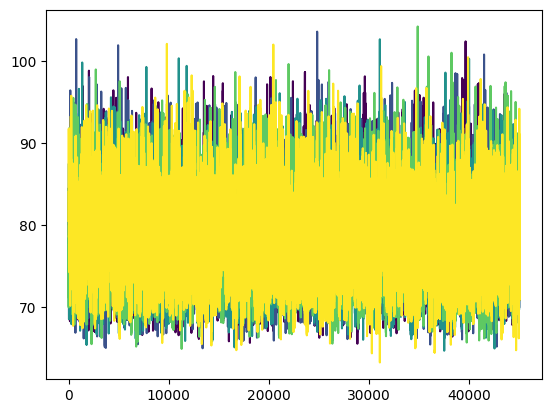

In [12]:
plt.figure()
for i in range(hmc_config["nch"]):
    plt.plot(energy_values[i,5000:], color = colors[i])
plt.savefig(f"{output_dir}/energy.jpg")
plt.show()

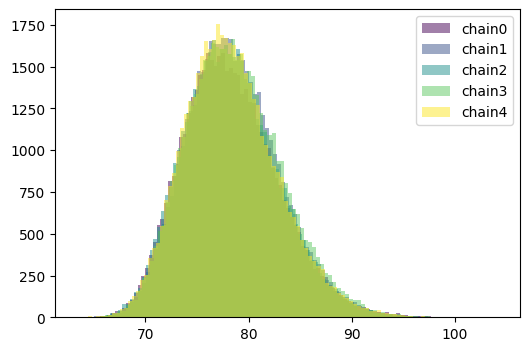

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(hmc_config["nch"]):
    ax.hist(energy_values[i, 2000:], color = colors[i], alpha = 0.5, label = f"chain{i}", bins = 100)
plt.legend()
plt.savefig(f"{output_dir}/energy_hist.jpg")
plt.show()   